# K-Means Clustering: Discovering Hidden Patterns

After analyzing features, we use **K-Means** to see if the data naturally forms distinct clusters. Since high-dimensional data (many features) is impossible to visualize, we use **PCA (Principal Component Analysis)** to project the features into a 2D space.

## 🎯 Process:
1. **Standardization:** K-Means uses Euclidean distance, so we must scale all features to a mean of 0 and variance of 1.
2. **K-Means Execution:** We set $K=2$ to see if the algorithm can "blindly" separate Benign from Malware samples.
3. **PCA Projection:** Reducing dimensions to 2D ($PC1$ and $PC2$) to visualize the cluster separation.

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. LOAD DATA
print("📂 Loading data...")
# Drop MD5, keep Label to compare
df = pd.read_csv("../data/malware_data_final.csv").drop_duplicates(subset=['MD5'])
X = df.drop(columns=['MD5', 'Label'])
y_true = df['Label']

📂 Loading data...


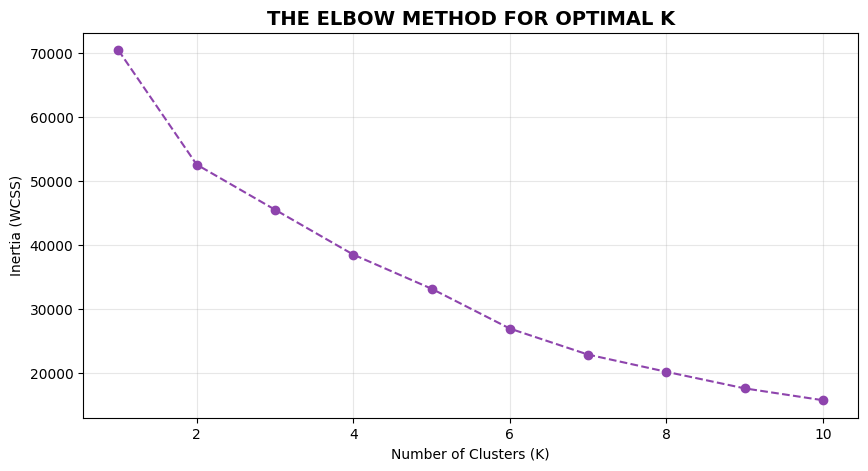

✅ Model & Scaler saved! Data grouped into 2 clusters.


In [3]:
# --- 2. FEATURE SCALING ---
# K-Means is extremely sensitive to the scale of data (Euclidean distance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. THE ELBOW METHOD ---
# To find the most efficient number of clusters
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Visualizing the Elbow
plt.figure(figsize=(10, 5))
plt.plot(k_range, wcss, marker='o', color='#8e44ad', linestyle='--')
plt.title('THE ELBOW METHOD FOR OPTIMAL K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True, alpha=0.3)
plt.show()

# --- 4. TRAIN FINAL K-MEANS MODEL ---
# Assuming K=2 (Benign vs Malware) based on our knowledge
final_k = 2
kmeans_model = KMeans(n_clusters=final_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_model.fit_predict(X_scaled)

# Add results back to dataframe
df['Cluster'] = clusters

# --- 5. SAVE THE MODEL & SCALER ---
# Professional step: Save for later inference on new files
joblib.dump(kmeans_model, '../models/kmeans_malware_model.pkl')
joblib.dump(scaler, '../models/feature_scaler.pkl')

print(f"✅ Model & Scaler saved! Data grouped into {final_k} clusters.")

## Visualizing the Clusters & Ground Truth Comparison

Since our dataset contains many features, visualizing the raw data is impossible. We use **Principal Component Analysis (PCA)** to project the data into a 2D space while retaining as much variance as possible.

### 🎯 Objectives:
* **PCA Projection:** Reduce dimensions to $PC1$ and $PC2$ for plotting.
* **Clustering Audit:** Compare the **Unsupervised Clusters** side-by-side with the **Actual Labels**. This reveals if the malware naturally separates from benign files based on structure alone.
* **Information Retained:** Check the `Explained Variance` to see how much of the original data "story" is still visible in 2D.

> **Note:** If the two plots look similar, the features are highly discriminative. If they look different, it indicates that the structural features alone (without labels) are not enough for K-Means to distinguish threats from safe files.

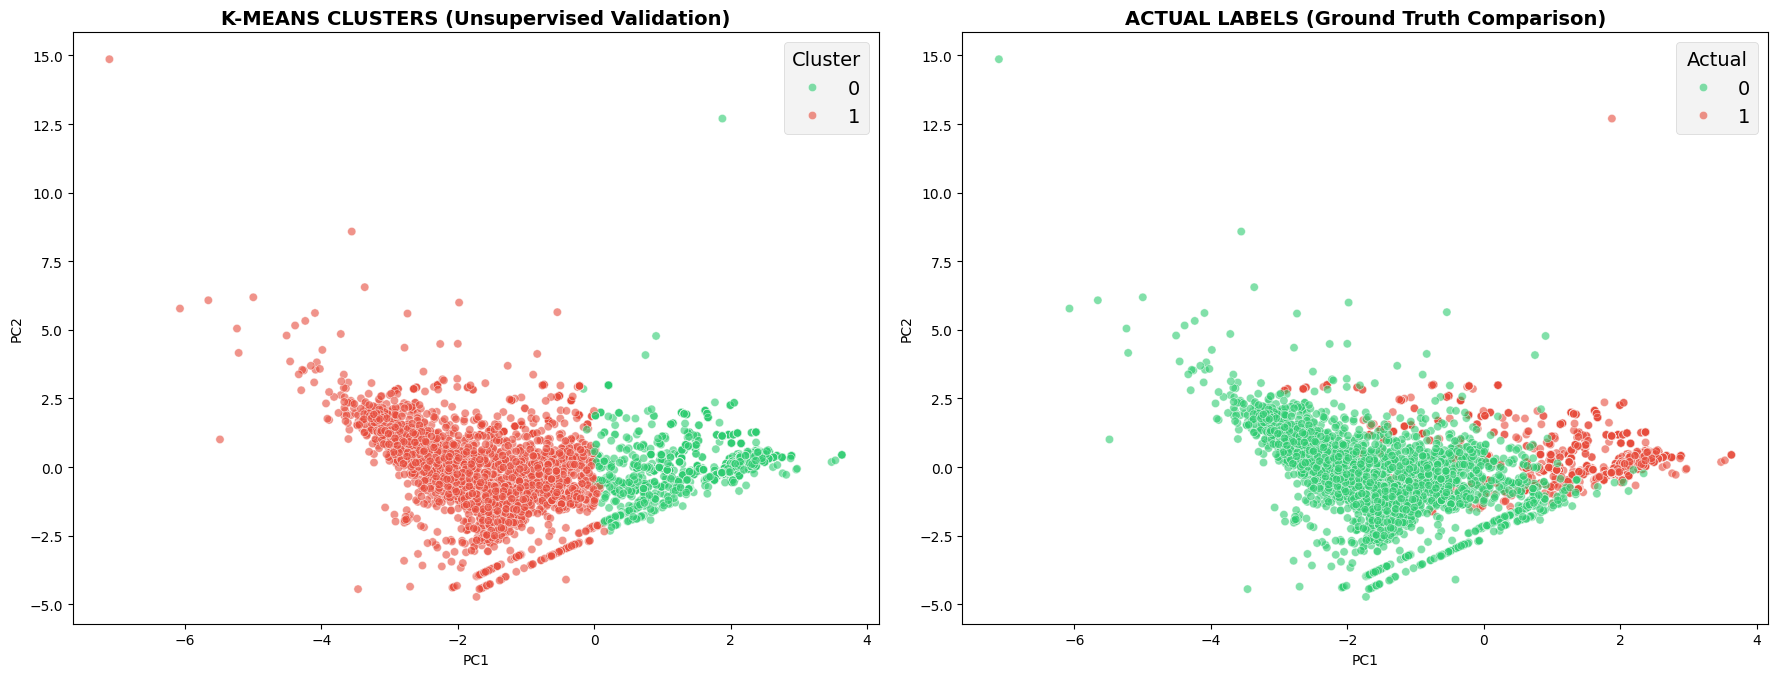

💡 Total Information Retained in 2D: 46.73%

--- CLUSTER VS ACTUAL LABEL CROSS-TAB ---
Cluster     0     1
Actual             
0         314  2560
1        3214   951


In [ ]:
# --- 4.2.2 PCA & K-MEANS CLUSTERING VISUALIZATION ---

# 1. Reduce dimensions to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create plotting dataframe
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters
df_pca['Actual'] = y_true.values

# 2. Plotting Comparison
fig, ax = plt.subplots(1, 2, figsize=(18, 7))
plt.style.use('fivethirtyeight')

# Color Mapping: 0 (Benign) = Green, 1 (Malware) = Red
colors_map = {0: '#2ecc71', 1: '#e74c3c'}

# Plot 1: K-Means Clusters (Unsupervised)
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette=colors_map, ax=ax[0], alpha=0.6)
ax[0].set_title('K-MEANS CLUSTERS (Unsupervised Validation)', fontsize=14, fontweight='bold')

# Plot 2: Actual Labels (Ground Truth)
sns.scatterplot(x='PC1', y='PC2', hue='Actual', data=df_pca, palette=colors_map, ax=ax[1], alpha=0.6)
ax[1].set_title('ACTUAL LABELS (Ground Truth Comparison)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Validation Metrics
print(f"💡 Total Information Retained in 2D: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print("\n--- CLUSTER VS ACTUAL LABEL CROSS-TAB ---")
print(pd.crosstab(df_pca['Actual'], df_pca['Cluster']))

In [ ]:
# Assuming:
# clusters: the result from kmeans.fit_predict()
# y_true: the true labels from the dataset (0: Benign, 1: Malicious)

# Method 1: Mapping - Determining which cluster is Malicious
# Calculate the proportion of '1' labels in each cluster
prop_cluster_0 = y_true[clusters == 0].mean()
prop_cluster_1 = y_true[clusters == 1].mean()

# If the proportion of '1' labels in cluster 1 is higher than in cluster 0, then Cluster 1 is Malicious (label 1)
if prop_cluster_1 > prop_cluster_0:
    kmeans_preds = clusters
else:
    # If not, reverse the labels to calculate accuracy correctly
    kmeans_preds = np.where(clusters == 1, 0, 1)

# Method 2: Calculating metrics
print(f"--- K-MEANS EVALUATION ---")
print(f"Accuracy:  {accuracy_score(y_true, kmeans_preds):.4f}")
print(f"Precision: {precision_score(y_true, kmeans_preds):.4f}")
print(f"Recall:    {recall_score(y_true, kmeans_preds):.4f}")
print(f"F1-Score:  {f1_score(y_true, kmeans_preds):.4f}")

--- K-MEANS EVALUATION ---
Accuracy:  0.8203
Precision: 0.9110
Recall:    0.7717
F1-Score:  0.8356
